In [1]:
import numpy as np
import matplotlib.pyplot as plt

import legume
from legume import GuidedModeExp, Circle, Ring, ShapesLayer

%load_ext autoreload
%autoreload 2

## Define W1 waveguide with a supercell

In [3]:
# PhC parameters
a_nm = 250            # lattice constant in nm — change this to rescale the simulation
D = 170 / a_nm          # slab thickness in units of a (always 170 nm physical)
ra = 75 / a_nm           # hole radius in units of a
n_slab = 3.46
eps_b = n_slab**2       # background permittivity
eps_c = 1               # hole permittivity (air)
eps_lower, eps_upper = 1, 1  # cladding permittivities

# supercell parameters
Ny = 12      # Number of rows in the y-direction
Nx = 1       # Supercell size in the x-direction
if (Ny%2 != 0): raise ValueError('number of rows Ny must be even')
Nholes = Nx*(Ny-1)    # total number of holes

# Initialize a rectangular lattice
lattice = legume.Lattice([Nx, 0], [0, Ny*np.sqrt(3)/2])

In [4]:
def build_w1_waveguide():
    """Build the standard W1 photonic crystal waveguide supercell.
    The structure is symmetric wrt a xz mirror plane,
    which allows disentangling modes with different kz-symmetry.
    """
    phc = legume.PhotCryst(lattice, eps_l=eps_lower, eps_u=eps_upper)
    phc.add_layer(d=D, eps_b=eps_b)

    xc = []; yc = []; rc = []
    jhole = 0

    for ih in range(1, Ny//2+1):
        for ix in range(-Nx//2+1, Nx//2+1):
            xc.append((ih%2)*0.5 + ix)
            yc.append( ih*np.sqrt(3)/2)
            rc.append(ra)
            jhole += 1
            # upper edge row is half-holes; skip the lower symmetric copy to avoid double counting
            if ih != Ny//2:
                xc.append((ih%2)*0.5 + ix)
                yc.append(-ih*np.sqrt(3)/2)
                rc.append(ra)
                jhole += 1

    for n in range(jhole):
        phc.layers[-1].add_shape(legume.Circle(eps=eps_c, r=rc[n], x_cent=xc[n], y_cent=yc[n]))

    return phc, jhole

Nholes, Nholes_check = 11 11
npw = 255


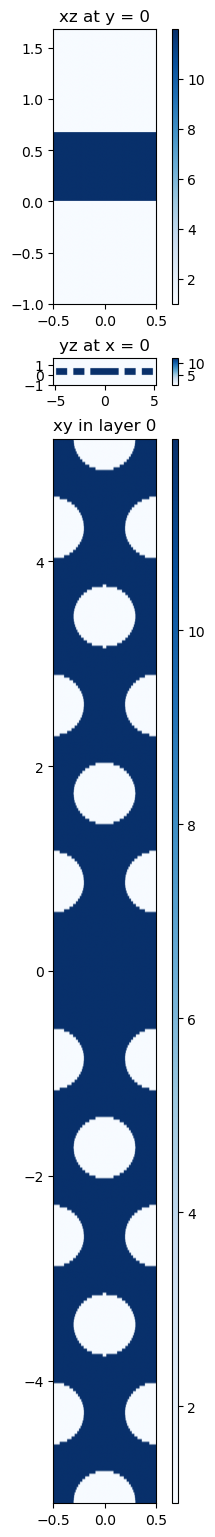

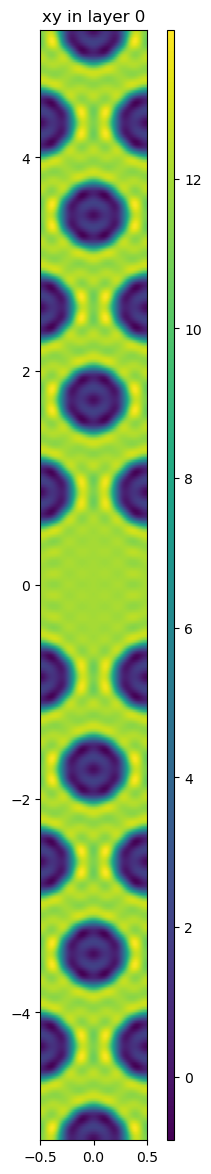

In [ ]:
# Initialize the photonic crystal
phc0, Nholes_check = build_w1_waveguide()
print('Nholes, Nholes_check =', Nholes, Nholes_check)

# Visualize the structure
legume.viz.structure(phc0, xz=True, yz=True, figsize=2, cmap='Blues', Nx=400, Ny=400, Nz=200)

gmax = 2.5
truncate_g = 'tbt'
gme0 = legume.GuidedModeExp(phc0, gmax=gmax, truncate_g=truncate_g)
npw = np.shape(gme0.gvec)[1]
print('npw =', npw)

legume.viz.eps_ft(gme0, Nx=400, Ny=400, figsize=1, cbar=True, cmap='viridis')

In [6]:
kz_symmetry = 'odd'

# Define a BZ path in kx and run the GME
# we reduce the number of k-points, to reduce the computing time later
nintervals = 30
nk = nintervals +1
path = lattice.bz_path([[0, 0], np.array([np.pi/Nx, 0])], [nintervals])

kpoints = path['kpoints']
#print(kpoints)

# change of basis for symmetrization can be done with dense or sparse matrices
# in this example with a low number of plane waves they are almost equivalent
# sparse matrices have a more favourable scaling with the number of plane waves
# symmetrization + sparse matrices + autograd is the newest feature of the code, still in beta-testing
use_sparse = True

# we consider only xy-even (TE-like) modes: this is the only polarization yielding a photonic band gap
gmode_inds, numeig = [0], 50

gme0 = legume.GuidedModeExp(phc0, gmax=gmax, truncate_g=truncate_g)
gme0.run(kpoints=path['kpoints'],
        gmode_inds=gmode_inds,
        numeig=numeig,
        verbose=True,
        compute_im=False,
        eig_sigma = 0.0,
        use_sparse=use_sparse,
        kz_symmetry=kz_symmetry, angles=path['angles']
        )

freqs = gme0.freqs
nfreq = np.shape(freqs)[1]
print(freqs.shape)


Running gme k-points: │------------------------------│ 1 of 31

3.335s total time for real part of frequencies in GuidedModeExp, of which
  1.100s (33%) for guided modes computation using the gmode_compute='exact' method
  0.004s (0%) for inverse matrix of Fourier-space permittivity
  1.283s (38%) for matrix diagionalization using the 'eigh' solver
  0.675s (20%) for creating GME matrix
  0.245s (7%) for creating change of basis matrix and multiply it using sparse matrices
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes
(31, 50)


(0.2, 0.4)

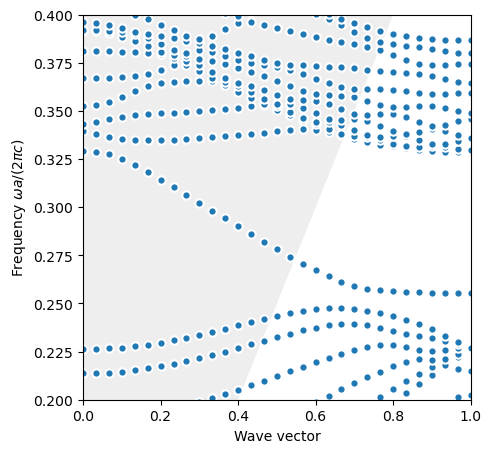

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
legume.viz.bands(gme0, ax=ax, k_units=True, Q=False)
ax.set_ylim([0.2, 0.4])

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_5850/1569531143.py:6: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel('$a k_x/ \pi$')


Text(0, 0.5, 'Frequency')

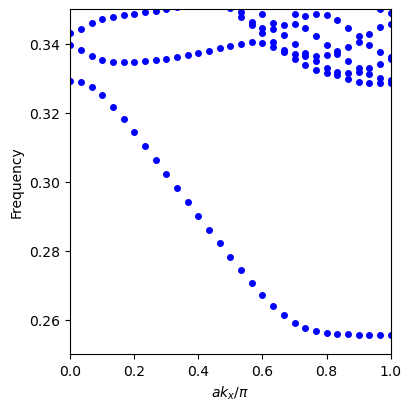

In [8]:
# Plot the (folded) waveguide bands
fig, ax = plt.subplots(1, constrained_layout=True, figsize=(4, 4))
ax.plot(kpoints[0, :]/np.pi, freqs, 'bo', markersize=4)
ax.set_ylim([0.25, 0.35])
ax.set_xlim([0, kpoints[0, -1]/np.pi])
ax.set_xlabel('$a k_x/ \pi$')
ax.set_ylabel('Frequency')

In [9]:
# ---- Select waveguide band (inspect plot above) ----
b_target = 7       # Index of the waveguide defect band

# ---- Extract waveguide band ----
kx = path['kpoints'][0, :]
wg_band = freqs[:, b_target]

# ---- Waveguide band metrics ----
wg_freq_min, wg_freq_max = wg_band.min(), wg_band.max()
wg_bandwidth = wg_freq_max - wg_freq_min
wg_center = (wg_freq_max + wg_freq_min) / 2

# ---- Band edge wavelength ----
f_edge = wg_band[-1]                        # normalized freq at BZ edge
lambda_edge_nm = a_nm / f_edge              # band edge wavelength in nm
lambda_edge_um = lambda_edge_nm / 1000      # band edge wavelength in µm

# ---- Group velocity: v_g = dω/dk (finite differences) ----
dk = np.diff(kx)
domega = np.diff(wg_band)
vg = domega / dk
kx_vg = (kx[:-1] + kx[1:]) / 2
ng = 1.0 / np.abs(vg)

# ---- Print summary ----
print("=" * 50)
print("BAND STRUCTURE METRICS")
print("=" * 50)
print(f"\nWaveguide Band (index {b_target}):")
print(f"  Freq min:          {wg_freq_min:.4f}")
print(f"  Freq max:          {wg_freq_max:.4f}")
print(f"  Bandwidth:         {wg_bandwidth:.4f}")
print(f"  Center frequency:  {wg_center:.4f}")
print(f"\nBand Edge:")
print(f"  f_edge (norm):     {f_edge:.4f}")
print(f"  lambda_edge:       {lambda_edge_nm:.1f} nm  ({lambda_edge_um:.4f} µm)")
print(f"\nGroup Velocity / Index:")
print(f"  v_g range:         [{vg.min():.4f}, {vg.max():.4f}]")
print(f"  n_g range:         [{ng.min():.2f}, {ng.max():.2f}]")
print(f"  n_g at zone edge:  {ng[-1]:.2f}")
print("=" * 50)

BAND STRUCTURE METRICS

Waveguide Band (index 7):
  Freq min:          0.2555
  Freq max:          0.3293
  Bandwidth:         0.0737
  Center frequency:  0.2924

Band Edge:
  f_edge (norm):     0.2555
  lambda_edge:       978.3 nm  (0.9783 µm)

Group Velocity / Index:
  v_g range:         [-0.0388, -0.0001]
  n_g range:         [25.79, 14043.31]
  n_g at zone edge:  14043.31


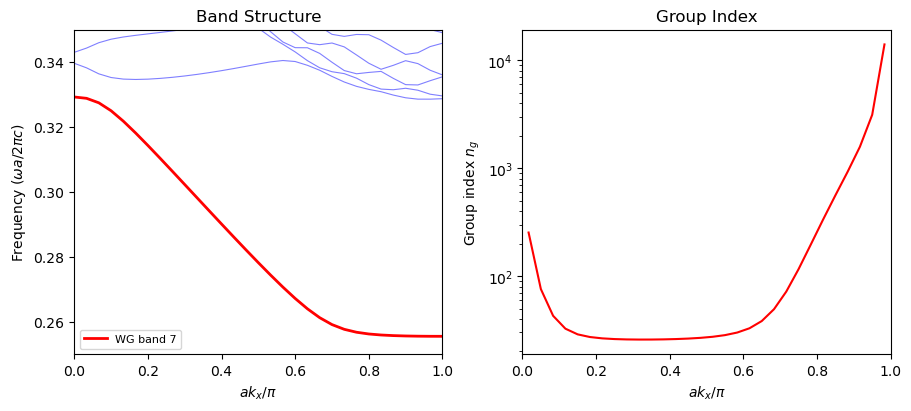

In [10]:
# ---- Band structure + group index plot ----
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(9, 4))

kx_norm = kx / np.pi
ax1.plot(kx_norm, freqs, 'b-', linewidth=0.8, alpha=0.5)
ax1.plot(kx_norm, wg_band, 'r-', linewidth=2, label=f'WG band {b_target}')
ax1.set_ylim([0.25, 0.35])
ax1.set_xlim([0, kx_norm[-1]])
ax1.set_xlabel(r'$a k_x / \pi$')
ax1.set_ylabel(r'Frequency ($\omega a / 2\pi c$)')
ax1.set_title('Band Structure')
ax1.legend(fontsize=8)

ax2.plot(kx_vg / np.pi, ng, 'r-', linewidth=1.5)
ax2.set_xlabel(r'$a k_x / \pi$')
ax2.set_ylabel(r'Group index $n_g$')
ax2.set_xlim([0, kx_norm[-1]])
ax2.set_title('Group Index')
ax2.set_yscale('log')

plt.show()

## Oxidized-hole W1 waveguide
Each air hole gets a thin oxide layer on its inner wall.  
Structure (radially outward): **air core** → **oxide ring** → **GaAs**

eps_ft for t_ox = 10.0 nm (oxide layers + rings should be visible)


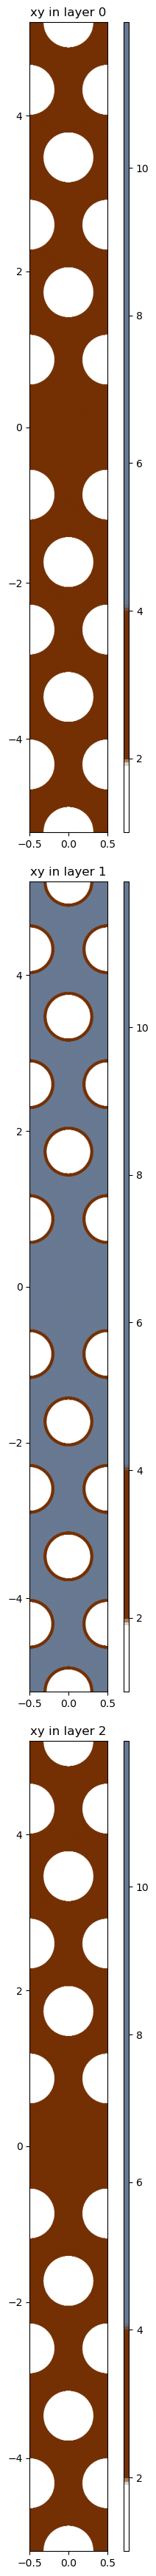

In [11]:
# Oxide parameters
n_oxide = 1.72
eps_oxide = n_oxide**2                         # Oxide permittivity                         
t_ox_values = np.linspace(0.5, 10, 20)        # oxide thicknesses to sweep (in nm)

def build_w1_waveguide_oxidized(t_ox_nm, consume_ratio=0.5):
    """Build a W1 waveguide with oxide on all exposed surfaces.

    Oxide grows both into the GaAS (consuming it) and outward (adding
    volume).  The consume_ratio controls the split, applied to both
    top/bottom slab surfaces and hole sidewalls.

    Parameters
    ----------
    t_ox_nm : float
        Total oxide thickness in nm.  Set to 0 for unoxidized waveguide.
    consume_ratio : float, optional
        Fraction of oxide that replaces GaAS (0-1).  Default 0.5.
        0 = all oxide added as extra volume (no GaAS consumed).
        1 = all oxide replaces GaAS (no extra volume added).
    """
    t_ox = t_ox_nm / a_nm                      # nm → units of a

    if t_ox_nm > 0:
        d_consume = consume_ratio * t_ox
        d_slab_eff = D - 2 * d_consume
        if d_slab_eff <= 0:
            raise ValueError(
                f'Oxide consumes entire slab: 2*{consume_ratio}*{t_ox_nm} nm '
                f'>= slab = {D * a_nm} nm')
        r_outer = ra + consume_ratio * t_ox
        r_inner = ra - (1 - consume_ratio) * t_ox
    else:
        d_slab_eff = D

    phc = legume.PhotCryst(lattice, eps_l=eps_lower, eps_u=eps_upper)

    if t_ox_nm > 0:
        phc.add_layer(d=t_ox, eps_b=eps_oxide)        # layer 0: bottom oxide
        phc.add_layer(d=d_slab_eff, eps_b=eps_b)      # layer 1: thinned slab
        phc.add_layer(d=t_ox, eps_b=eps_oxide)         # layer 2: top oxide
        slab_idx = 1
    else:
        phc.add_layer(d=D, eps_b=eps_b)                # layer 0: full slab
        slab_idx = 0

    xc = []; yc = []
    jhole = 0

    for ih in range(1, Ny//2+1):
        for ix in range(-Nx//2+1, Nx//2+1):
            xc.append((ih%2)*0.5 + ix)
            yc.append( ih*np.sqrt(3)/2)
            jhole += 1
            if ih != Ny//2:
                xc.append((ih%2)*0.5 + ix)
                yc.append(-ih*np.sqrt(3)/2)
                jhole += 1

    for n in range(jhole):
        if t_ox_nm > 0:
            # Slab layer: oxide ring + air core
            phc.layers[slab_idx].add_shape(
                Ring(eps=eps_oxide, r_i=r_inner, r_o=r_outer,
                     x_cent=xc[n], y_cent=yc[n]))
            phc.layers[slab_idx].add_shape(
                Circle(eps=eps_c, r=r_inner,
                       x_cent=xc[n], y_cent=yc[n]))
            # Oxide cladding layers: air holes punch through
            phc.layers[0].add_shape(
                Circle(eps=eps_c, r=r_outer,
                       x_cent=xc[n], y_cent=yc[n]))
            phc.layers[2].add_shape(
                Circle(eps=eps_c, r=r_outer,
                       x_cent=xc[n], y_cent=yc[n]))
        else:
            phc.layers[slab_idx].add_shape(
                Circle(eps=eps_c, r=ra,
                       x_cent=xc[n], y_cent=yc[n]))

    return phc, jhole

import matplotlib.colors as mcolors
cmap_discrete = mcolors.LinearSegmentedColormap.from_list('discrete_eps', [
    (0.00, 'white'),     # air
    (0.08, 'white'),
    (0.09, "#743003"),   # oxide
    (0.27, '#743003'),
    (0.28, "#687992"),   # GaAs
    (1.00, '#687992')
])

# Sanity-check visualization for the largest thickness
phc_check, _ = build_w1_waveguide_oxidized(t_ox_values[-1])
gme_check = legume.GuidedModeExp(phc_check, gmax=gmax, truncate_g=truncate_g)
print(f"eps_ft for t_ox = {t_ox_values[-1]:.1f} nm (oxide layers + rings should be visible)")
# Visualize the structure
legume.viz.structure(phc_check, xz=False, yz=False, xy=True, figsize=2, cmap=cmap_discrete, Nx=400, Ny=1400, Nz=200)
#legume.viz.eps_ft(gme_check, Nx=400, Ny=400, figsize=3, cbar=True, cmap='BuPu')

In [30]:
# ---- Sweep over oxide thicknesses ----
b_target_ox = b_target   # waveguide band index (adjust if needed)

results_ox = []

for t_ox_nm in t_ox_values:
    print(f"\n--- t_ox = {t_ox_nm:.1f} nm ---")
    phc_ox, _ = build_w1_waveguide_oxidized(t_ox_nm)
    gme_ox = legume.GuidedModeExp(phc_ox, gmax=gmax, truncate_g=truncate_g)
    gme_ox.run(kpoints=path['kpoints'],
               gmode_inds=gmode_inds,
               numeig=numeig,
               verbose=False,
               compute_im=False,
               eig_sigma=0.0,
               use_sparse=use_sparse,
               kz_symmetry=kz_symmetry, angles=path['angles'])

    freqs_ox   = gme_ox.freqs
    kx_ox      = path['kpoints'][0, :]
    wg_band_ox = freqs_ox[:, b_target_ox]
    vg_ox      = np.diff(wg_band_ox) / np.diff(kx_ox)
    kx_vg_ox   = (kx_ox[:-1] + kx_ox[1:]) / 2
    ng_ox      = 1.0 / np.abs(vg_ox)

    f_min, f_max = wg_band_ox.min(), wg_band_ox.max()
    f_edge_ox = wg_band_ox[-1]
    lam_edge_nm = a_nm / f_edge_ox
    lam_edge_um = lam_edge_nm / 1000

    print(f"  WG freq:   [{f_min:.4f}, {f_max:.4f}]   bw = {f_max-f_min:.4f}")
    print(f"  Band edge: {lam_edge_um:.4f} µm ({lam_edge_nm:.1f} nm)")
    print(f"  n_g range: [{ng_ox.min():.2f}, {ng_ox.max():.2f}]")

    results_ox.append({
        't_ox_nm': t_ox_nm,
        'freqs':   freqs_ox,
        'wg_band': wg_band_ox,
        'kx_vg':   kx_vg_ox,
        'ng':      ng_ox,
        'f_min':   f_min,
        'f_max':   f_max,
        'f_edge':  f_edge_ox,
        'lam_edge_nm': lam_edge_nm,
        'lam_edge_um': lam_edge_um,
        'bw':      f_max - f_min,
        'center':  (f_min + f_max) / 2,
        'ng_min':  ng_ox.min(),
        'ng_max':  ng_ox.max(),
        'ng_edge': ng_ox[-1],
    })

print("\nSweep complete.")


--- t_ox = 0.5 nm ---
  WG freq:   [0.2558, 0.3297]   bw = 0.0739
  Band edge: 0.9774 µm (977.4 nm)
  n_g range: [25.79, 14694.42]

--- t_ox = 1.0 nm ---
  WG freq:   [0.2560, 0.3301]   bw = 0.0741
  Band edge: 0.9766 µm (976.6 nm)
  n_g range: [25.79, 15399.23]

--- t_ox = 1.5 nm ---
  WG freq:   [0.2562, 0.3305]   bw = 0.0743
  Band edge: 0.9757 µm (975.7 nm)
  n_g range: [25.79, 16164.46]

--- t_ox = 2.0 nm ---
  WG freq:   [0.2565, 0.3309]   bw = 0.0744
  Band edge: 0.9748 µm (974.8 nm)
  n_g range: [25.79, 16998.01]

--- t_ox = 2.5 nm ---
  WG freq:   [0.2567, 0.3313]   bw = 0.0746
  Band edge: 0.9739 µm (973.9 nm)
  n_g range: [25.79, 17909.17]

--- t_ox = 3.0 nm ---
  WG freq:   [0.2569, 0.3317]   bw = 0.0747
  Band edge: 0.9730 µm (973.0 nm)
  n_g range: [25.79, 18909.03]

--- t_ox = 3.5 nm ---
  WG freq:   [0.2572, 0.3320]   bw = 0.0749
  Band edge: 0.9721 µm (972.1 nm)
  n_g range: [25.79, 20010.82]

--- t_ox = 4.0 nm ---
  WG freq:   [0.2574, 0.3324]   bw = 0.0750
  Band ed

## Comparison: Original vs Oxidized

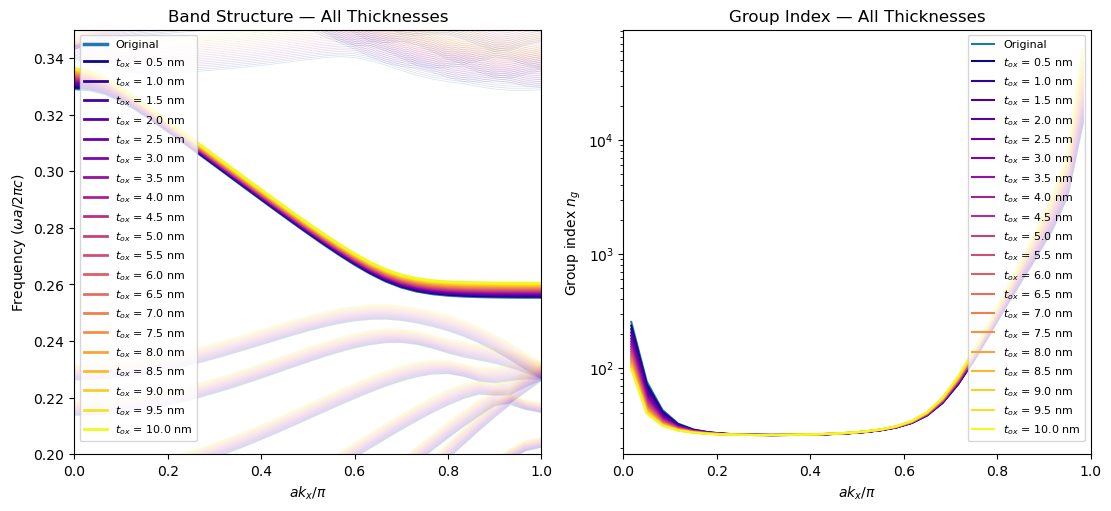

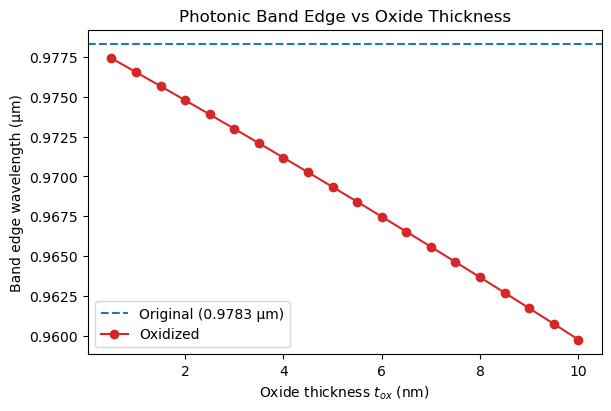

COMPARISON TABLE
 t_ox (nm)    f_edge      λ_edge     f_min     f_max        bw    ng_min   ng_edge
------------------------------------------------------------------------------------------
  original    0.2555     0.9783µm    0.2555    0.3293    0.0737     25.79  14043.31
       0.5    0.2558     0.9774µm    0.2558    0.3297    0.0739     25.79  14694.42
       1.0    0.2560     0.9766µm    0.2560    0.3301    0.0741     25.79  15399.23
       1.5    0.2562     0.9757µm    0.2562    0.3305    0.0743     25.79  16164.46
       2.0    0.2565     0.9748µm    0.2565    0.3309    0.0744     25.79  16998.01
       2.5    0.2567     0.9739µm    0.2567    0.3313    0.0746     25.79  17909.17
       3.0    0.2569     0.9730µm    0.2569    0.3317    0.0747     25.79  18909.03
       3.5    0.2572     0.9721µm    0.2572    0.3320    0.0749     25.79  20010.82
       4.0    0.2574     0.9712µm    0.2574    0.3324    0.0750     25.79  21230.55
       4.5    0.2577     0.9703µm    0.2577    0.3328

In [31]:
# ---- Overlay: original + all oxidized thicknesses ----
cmap = plt.cm.plasma
colors = [cmap(i / max(len(results_ox) - 1, 1)) for i in range(len(results_ox))]

kx_norm = kx / np.pi
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(11, 5))

# --- Band structures ---
ax1.plot(kx_norm, freqs, '-', color='tab:blue', linewidth=0.5, alpha=0.2)
ax1.plot(kx_norm, wg_band, '-', color='tab:blue', linewidth=2.5, label='Original')

for r, c in zip(results_ox, colors):
    ax1.plot(kx_norm, r['freqs'], '-', color=c, linewidth=0.5, alpha=0.15)
    ax1.plot(kx_norm, r['wg_band'], '-', color=c, linewidth=2,
             label=f"$t_{{ox}}$ = {r['t_ox_nm']:.1f} nm")

ax1.set_ylim([0.2, 0.35])
ax1.set_xlim([0, kx_norm[-1]])
ax1.set_xlabel(r'$a k_x / \pi$')
ax1.set_ylabel(r'Frequency ($\omega a / 2\pi c$)')
ax1.set_title('Band Structure — All Thicknesses')
ax1.legend(fontsize=8, loc='upper left')

# --- Group index ---
ax2.plot(kx_vg / np.pi, ng, '-', color='tab:blue', linewidth=1.5, label='Original')
for r, c in zip(results_ox, colors):
    ax2.plot(r['kx_vg'] / np.pi, r['ng'], '-', color=c, linewidth=1.5,
             label=f"$t_{{ox}}$ = {r['t_ox_nm']:.1f} nm")

ax2.set_xlabel(r'$a k_x / \pi$')
ax2.set_ylabel(r'Group index $n_g$')
ax2.set_xlim([0, kx_norm[-1]])
ax2.set_title('Group Index — All Thicknesses')
ax2.set_yscale('log')
ax2.legend(fontsize=8)

plt.show()

# ---- Band edge wavelength vs oxide thickness plot ----
fig2, ax3 = plt.subplots(1, 1, constrained_layout=True, figsize=(6, 4))
t_ox_arr = [r['t_ox_nm'] for r in results_ox]
lam_arr  = [r['lam_edge_um'] for r in results_ox]
ax3.axhline(lambda_edge_um, color='tab:blue', linestyle='--', label=f'Original ({lambda_edge_um:.4f} µm)')
ax3.plot(t_ox_arr, lam_arr, 'o-', color='tab:red', markersize=6, label='Oxidized')
ax3.set_xlabel(r'Oxide thickness $t_{ox}$ (nm)')
ax3.set_ylabel(r'Band edge wavelength (µm)')
ax3.set_title('Photonic Band Edge vs Oxide Thickness')
ax3.legend()
plt.show()

# ---- Metrics table ----
print("=" * 90)
print("COMPARISON TABLE")
print("=" * 90)
print(f"{'t_ox (nm)':>10}  {'f_edge':>8}  {'λ_edge':>10}  {'f_min':>8}  {'f_max':>8}  {'bw':>8}  {'ng_min':>8}  {'ng_edge':>8}")
print("-" * 90)
print(f"{'original':>10}  {f_edge:>8.4f}  {lambda_edge_um:>9.4f}µm  {wg_freq_min:>8.4f}  {wg_freq_max:>8.4f}  {wg_bandwidth:>8.4f}  {ng.min():>8.2f}  {ng[-1]:>8.2f}")
for r in results_ox:
    print(f"{r['t_ox_nm']:>10.1f}  {r['f_edge']:>8.4f}  {r['lam_edge_um']:>9.4f}µm  {r['f_min']:>8.4f}  {r['f_max']:>8.4f}  {r['bw']:>8.4f}  {r['ng_min']:>8.2f}  {r['ng_edge']:>8.2f}")
print("=" * 90)

## Band Edge Heatmap: Hole Radius vs Lattice Constant

In [17]:
# ---- Self-contained band edge computation ----
def compute_band_edge(a_nm_val, r_nm_val, t_ox=0, consume_ratio=0.5, hole_only=False):
    """Compute band edge wavelength (µm) for given physical parameters.

    Parameters
    ----------
    a_nm_val : float
        Lattice constant in nm.
    r_nm_val : float
        Hole radius in nm.
    t_ox : float
        Oxide thickness in units of a (normalized).
    consume_ratio : float, optional
        Fraction of oxide that replaces silicon (0-1).  Default 0.5.
    hole_only : bool, optional
        If True, oxide grows only on hole sidewalls — no top/bottom
        oxide cladding layers and no slab thinning.  Default False.
    """
    D_val  = 170 / a_nm_val
    ra_val = r_nm_val / a_nm_val

    phc = legume.PhotCryst(lattice, eps_l=eps_lower, eps_u=eps_upper)

    if t_ox > 0:
        r_outer = ra_val + consume_ratio * t_ox
        r_inner = ra_val - (1 - consume_ratio) * t_ox

    if t_ox > 0 and not hole_only:
        d_consume = consume_ratio * t_ox
        d_slab_eff = D_val - 2 * d_consume
        if d_slab_eff <= 0:
            raise ValueError(
                f'Oxide consumes entire slab: 2*{consume_ratio}*{t_ox*a_nm_val:.1f} nm '
                f'>= slab = 170 nm')

        phc.add_layer(d=t_ox, eps_b=eps_oxide)        # layer 0: bottom oxide
        phc.add_layer(d=d_slab_eff, eps_b=eps_b)      # layer 1: thinned slab
        phc.add_layer(d=t_ox, eps_b=eps_oxide)         # layer 2: top oxide
        slab_idx = 1
    else:
        phc.add_layer(d=D_val, eps_b=eps_b)            # single slab layer
        slab_idx = 0

    for ih in range(1, Ny//2+1):
        for ix in range(-Nx//2+1, Nx//2+1):
            xc = (ih%2)*0.5 + ix
            yc_pos = ih*np.sqrt(3)/2
            positions = [(xc, yc_pos), (xc, -yc_pos)] if ih != Ny//2 else [(xc, yc_pos)]
            for (x, y) in positions:
                if t_ox > 0:
                    phc.layers[slab_idx].add_shape(
                        Ring(eps=eps_oxide, r_i=r_inner, r_o=r_outer,
                             x_cent=x, y_cent=y))
                    phc.layers[slab_idx].add_shape(
                        Circle(eps=eps_c, r=r_inner, x_cent=x, y_cent=y))
                    if not hole_only:
                        phc.layers[0].add_shape(
                            Circle(eps=eps_c, r=r_outer, x_cent=x, y_cent=y))
                        phc.layers[2].add_shape(
                            Circle(eps=eps_c, r=r_outer, x_cent=x, y_cent=y))
                else:
                    phc.layers[slab_idx].add_shape(
                        Circle(eps=eps_c, r=ra_val, x_cent=x, y_cent=y))

    gme = legume.GuidedModeExp(phc, gmax=gmax, truncate_g=truncate_g)
    gme.run(kpoints=path['kpoints'], gmode_inds=gmode_inds, numeig=numeig,
            verbose=False, compute_im=False, eig_sigma=0.0,
            use_sparse=use_sparse, kz_symmetry=kz_symmetry, angles=path['angles'])

    f_edge = gme.freqs[-1, b_target]
    return a_nm_val / f_edge / 1000  # λ_edge in µm

In [33]:

# ---- Sweep parameters ----
r_nm_values = np.linspace(70, 84, 5)        # hole radius in nm
a_nm_values = np.arange(246, 254, 2)      # lattice constant in nm
t_ox_nm_sweep  = [0, 1, 3, 5]             # oxide thicknesses in nm
t_ox_nm_labels = ['No oxide',
                  r'$t_{ox}=1\,$nm',
                  r'$t_{ox}=3\,$nm',
                  r'$t_{ox}=5\,$nm']

n_total = len(t_ox_nm_sweep) * len(a_nm_values) * len(r_nm_values)
heatmap_data = {}

count = 0
for t_ox_nm in t_ox_nm_sweep:
    data = np.zeros((len(a_nm_values), len(r_nm_values)))
    for ia, a_val in enumerate(a_nm_values):
        for ir, r_val in enumerate(r_nm_values):
            count += 1
            t_ox_norm = t_ox_nm / a_val      # nm → units of a
            lam = compute_band_edge(a_val, r_val, t_ox=t_ox_norm)
            data[ia, ir] = lam
            print(f"[{count}/{n_total}] t_ox={t_ox_nm}nm, a={a_val}nm, r={r_val}nm → λ_edge={lam:.4f} µm")
    heatmap_data[t_ox_nm] = data

print("\nHeatmap sweep complete.")

[1/80] t_ox=0nm, a=246nm, r=70.0nm → λ_edge=0.9780 µm
[2/80] t_ox=0nm, a=246nm, r=73.5nm → λ_edge=0.9667 µm
[3/80] t_ox=0nm, a=246nm, r=77.0nm → λ_edge=0.9548 µm
[4/80] t_ox=0nm, a=246nm, r=80.5nm → λ_edge=0.9423 µm
[5/80] t_ox=0nm, a=246nm, r=84.0nm → λ_edge=0.9288 µm
[6/80] t_ox=0nm, a=248nm, r=70.0nm → λ_edge=0.9862 µm
[7/80] t_ox=0nm, a=248nm, r=73.5nm → λ_edge=0.9749 µm
[8/80] t_ox=0nm, a=248nm, r=77.0nm → λ_edge=0.9632 µm
[9/80] t_ox=0nm, a=248nm, r=80.5nm → λ_edge=0.9509 µm
[10/80] t_ox=0nm, a=248nm, r=84.0nm → λ_edge=0.9376 µm
[11/80] t_ox=0nm, a=250nm, r=70.0nm → λ_edge=0.9943 µm
[12/80] t_ox=0nm, a=250nm, r=73.5nm → λ_edge=0.9832 µm
[13/80] t_ox=0nm, a=250nm, r=77.0nm → λ_edge=0.9716 µm
[14/80] t_ox=0nm, a=250nm, r=80.5nm → λ_edge=0.9594 µm
[15/80] t_ox=0nm, a=250nm, r=84.0nm → λ_edge=0.9464 µm
[16/80] t_ox=0nm, a=252nm, r=70.0nm → λ_edge=1.0024 µm
[17/80] t_ox=0nm, a=252nm, r=73.5nm → λ_edge=0.9914 µm
[18/80] t_ox=0nm, a=252nm, r=77.0nm → λ_edge=0.9799 µm
[19/80] t_ox=0nm, a

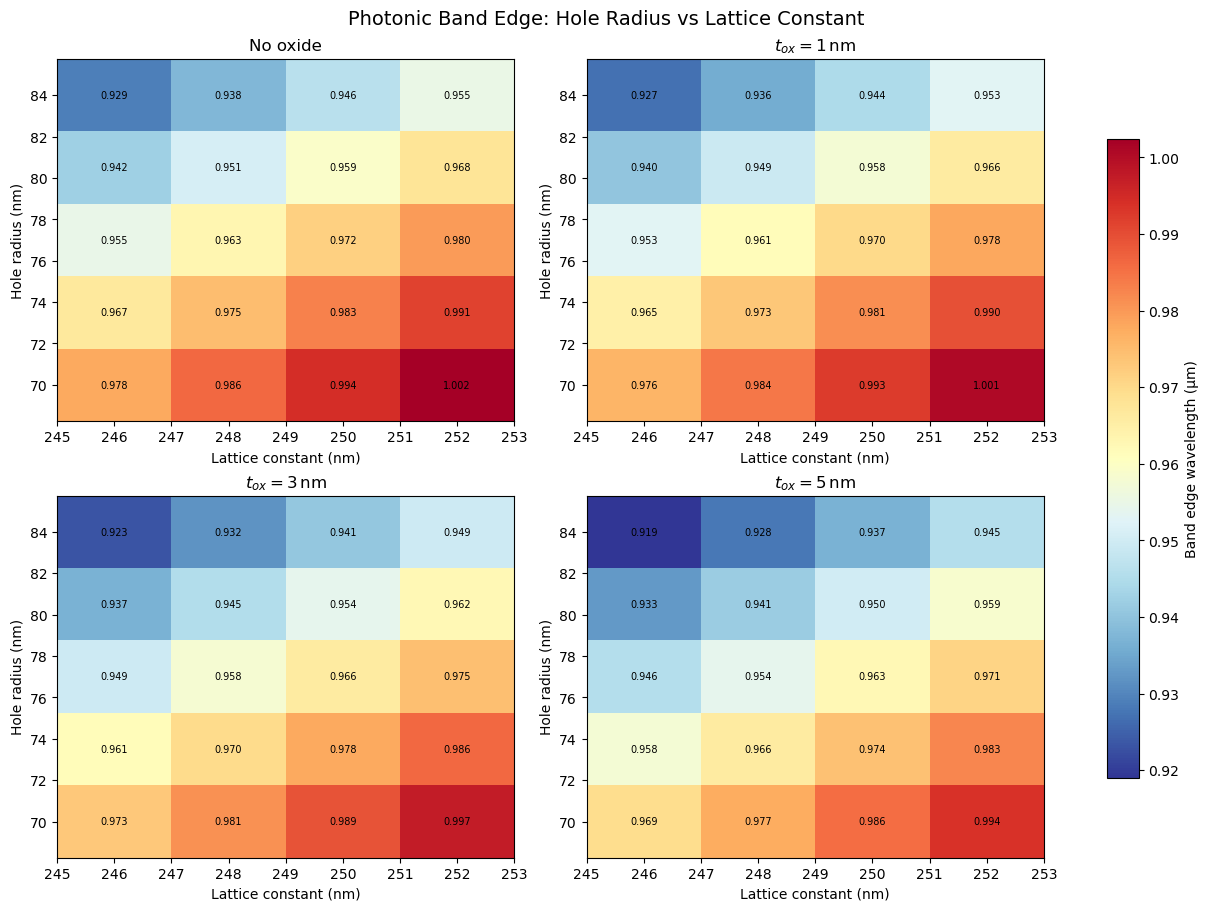

In [34]:
# ---- Band edge heatmaps ----
# Shared color range across all subplots
all_vals = np.concatenate([heatmap_data[t].ravel() for t in t_ox_nm_sweep])
vmin, vmax = all_vals.min(), all_vals.max()

fig, axes = plt.subplots(2, 2, constrained_layout=True, figsize=(12, 9))

for ax, t_ox_nm, label in zip(axes.ravel(), t_ox_nm_sweep, t_ox_nm_labels):
    im = ax.pcolormesh(a_nm_values, r_nm_values, heatmap_data[t_ox_nm].T,
                       cmap='RdYlBu_r', vmin=vmin, vmax=vmax, shading='nearest')
    ax.set_xlabel('Lattice constant (nm)')
    ax.set_ylabel('Hole radius (nm)')
    ax.set_title(label)
    # Annotate each cell with the value
    for ia in range(len(a_nm_values)):
        for ir in range(len(r_nm_values)):
            ax.text(a_nm_values[ia], r_nm_values[ir],
                    f'{heatmap_data[t_ox_nm][ia, ir]:.3f}',
                    ha='center', va='center', fontsize=7, color='k')

fig.colorbar(im, ax=axes, label=r'Band edge wavelength (µm)', shrink=0.8)
fig.suptitle('Photonic Band Edge: Hole Radius vs Lattice Constant', fontsize=14)
plt.show()

## Band Edge Heatmap: Constant Physical Oxide Thickness
In the previous heatmap, `t_ox` is in units of `a`, so the **physical** oxide  
thickness varies with lattice constant. Here we fix the oxide thickness in  
absolute **nm** so it stays constant across the entire `a` sweep.

[1/80] t_ox=0nm (=0.0000a), a=246nm, r=70.0nm → λ_edge=0.9780 µm
[2/80] t_ox=0nm (=0.0000a), a=246nm, r=73.5nm → λ_edge=0.9667 µm
[3/80] t_ox=0nm (=0.0000a), a=246nm, r=77.0nm → λ_edge=0.9548 µm
[4/80] t_ox=0nm (=0.0000a), a=246nm, r=80.5nm → λ_edge=0.9423 µm
[5/80] t_ox=0nm (=0.0000a), a=246nm, r=84.0nm → λ_edge=0.9288 µm
[6/80] t_ox=0nm (=0.0000a), a=248nm, r=70.0nm → λ_edge=0.9862 µm
[7/80] t_ox=0nm (=0.0000a), a=248nm, r=73.5nm → λ_edge=0.9749 µm
[8/80] t_ox=0nm (=0.0000a), a=248nm, r=77.0nm → λ_edge=0.9632 µm
[9/80] t_ox=0nm (=0.0000a), a=248nm, r=80.5nm → λ_edge=0.9509 µm
[10/80] t_ox=0nm (=0.0000a), a=248nm, r=84.0nm → λ_edge=0.9376 µm
[11/80] t_ox=0nm (=0.0000a), a=250nm, r=70.0nm → λ_edge=0.9943 µm
[12/80] t_ox=0nm (=0.0000a), a=250nm, r=73.5nm → λ_edge=0.9832 µm
[13/80] t_ox=0nm (=0.0000a), a=250nm, r=77.0nm → λ_edge=0.9716 µm
[14/80] t_ox=0nm (=0.0000a), a=250nm, r=80.5nm → λ_edge=0.9594 µm
[15/80] t_ox=0nm (=0.0000a), a=250nm, r=84.0nm → λ_edge=0.9464 µm
[16/80] t_ox=0nm (=

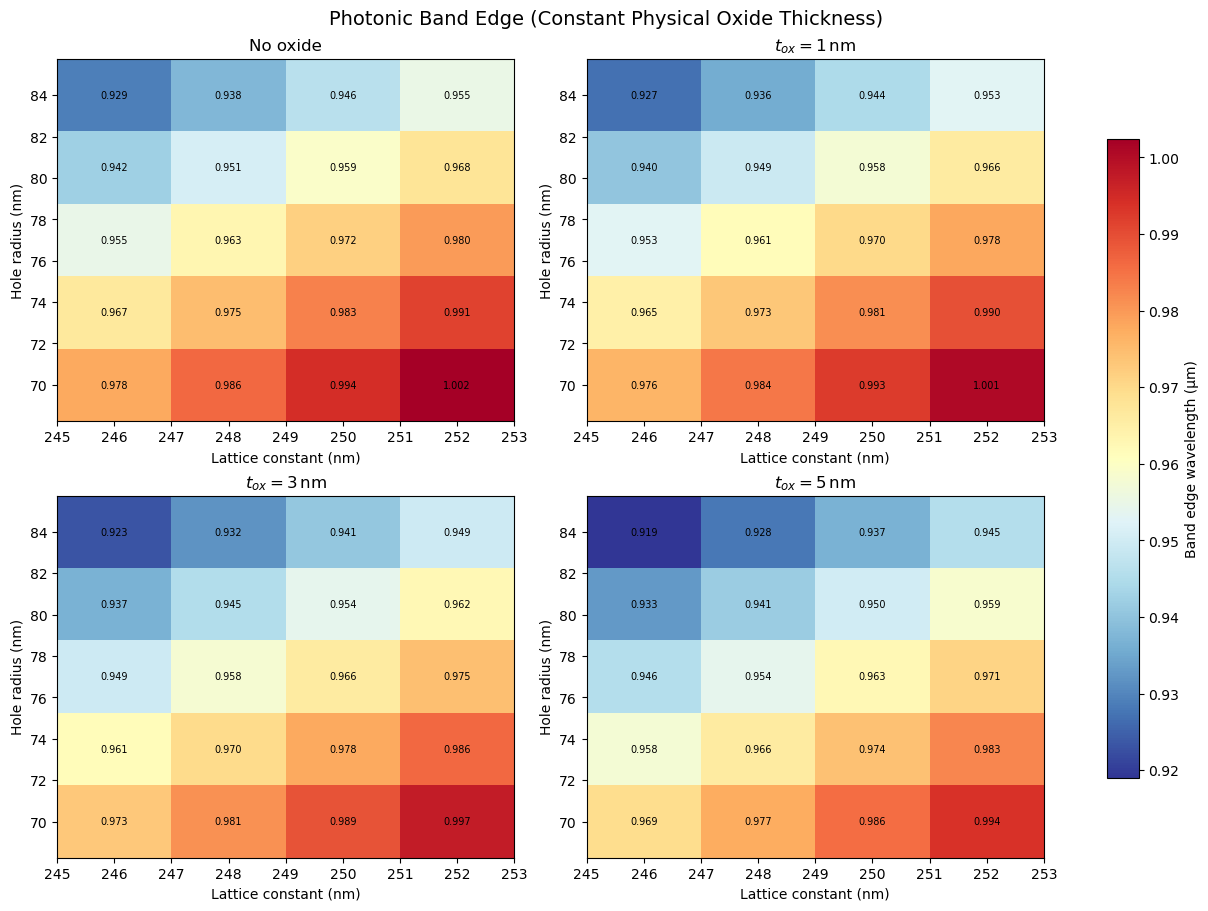

In [35]:
# ---- Band edge heatmap: CONSTANT physical oxide thickness (nm) ----
# t_ox in nm → normalized per a-value as t_ox_norm = t_ox_nm / a_nm
t_ox_nm_sweep  = [0, 1, 3, 5]            # physical oxide thickness in nm
t_ox_nm_labels = ['No oxide',
                  r'$t_{ox}=1\,$nm',
                  r'$t_{ox}=3\,$nm',
                  r'$t_{ox}=5\,$nm']

n_total_abs = len(t_ox_nm_sweep) * len(a_nm_values) * len(r_nm_values)
heatmap_data_abs = {}

count = 0
for t_ox_nm in t_ox_nm_sweep:
    data = np.zeros((len(a_nm_values), len(r_nm_values)))
    for ia, a_val in enumerate(a_nm_values):
        for ir, r_val in enumerate(r_nm_values):
            count += 1
            t_ox_norm = t_ox_nm / a_val          # nm → units of a
            lam = compute_band_edge(a_val, r_val, t_ox=t_ox_norm)
            data[ia, ir] = lam
            print(f"[{count}/{n_total_abs}] t_ox={t_ox_nm}nm (={t_ox_norm:.4f}a), "
                  f"a={a_val}nm, r={r_val}nm → λ_edge={lam:.4f} µm")
    heatmap_data_abs[t_ox_nm] = data

print("\nHeatmap sweep (constant physical oxide) complete.")

# ---- Plot ----
all_vals_abs = np.concatenate([heatmap_data_abs[t].ravel() for t in t_ox_nm_sweep])
vmin_abs, vmax_abs = all_vals_abs.min(), all_vals_abs.max()

fig, axes = plt.subplots(2, 2, constrained_layout=True, figsize=(12, 9))

for ax, t_ox_nm, label in zip(axes.ravel(), t_ox_nm_sweep, t_ox_nm_labels):
    im = ax.pcolormesh(a_nm_values, r_nm_values, heatmap_data_abs[t_ox_nm].T,
                       cmap='RdYlBu_r', vmin=vmin_abs, vmax=vmax_abs, shading='nearest')
    ax.set_xlabel('Lattice constant (nm)')
    ax.set_ylabel('Hole radius (nm)')
    ax.set_title(label)
    for ia in range(len(a_nm_values)):
        for ir in range(len(r_nm_values)):
            ax.text(a_nm_values[ia], r_nm_values[ir],
                    f'{heatmap_data_abs[t_ox_nm][ia, ir]:.3f}',
                    ha='center', va='center', fontsize=7, color='k')

fig.colorbar(im, ax=axes, label=r'Band edge wavelength (µm)', shrink=0.8)
fig.suptitle('Photonic Band Edge (Constant Physical Oxide Thickness)', fontsize=14)
plt.show()

## Band Edge vs Oxide Thickness: Parameter Sweeps
Each plot shows band edge wavelength as a function of oxide thickness,  
with multiple curves for different structural parameters.

[1/80] r=70.0nm, t_ox=0.0nm → λ_edge=0.9943 µm
[2/80] r=70.0nm, t_ox=0.3nm → λ_edge=0.9938 µm
[3/80] r=70.0nm, t_ox=0.6nm → λ_edge=0.9932 µm
[4/80] r=70.0nm, t_ox=0.9nm → λ_edge=0.9927 µm
[5/80] r=70.0nm, t_ox=1.3nm → λ_edge=0.9922 µm
[6/80] r=70.0nm, t_ox=1.6nm → λ_edge=0.9916 µm
[7/80] r=70.0nm, t_ox=1.9nm → λ_edge=0.9911 µm
[8/80] r=70.0nm, t_ox=2.2nm → λ_edge=0.9905 µm
[9/80] r=70.0nm, t_ox=2.5nm → λ_edge=0.9900 µm
[10/80] r=70.0nm, t_ox=2.8nm → λ_edge=0.9894 µm
[11/80] r=70.0nm, t_ox=3.2nm → λ_edge=0.9888 µm
[12/80] r=70.0nm, t_ox=3.5nm → λ_edge=0.9883 µm
[13/80] r=70.0nm, t_ox=3.8nm → λ_edge=0.9877 µm
[14/80] r=70.0nm, t_ox=4.1nm → λ_edge=0.9872 µm
[15/80] r=70.0nm, t_ox=4.4nm → λ_edge=0.9866 µm
[16/80] r=70.0nm, t_ox=4.7nm → λ_edge=0.9860 µm
[17/80] r=70.0nm, t_ox=5.1nm → λ_edge=0.9855 µm
[18/80] r=70.0nm, t_ox=5.4nm → λ_edge=0.9849 µm
[19/80] r=70.0nm, t_ox=5.7nm → λ_edge=0.9843 µm
[20/80] r=70.0nm, t_ox=6.0nm → λ_edge=0.9837 µm
[21/80] r=74.0nm, t_ox=0.0nm → λ_edge=0.9816 µm
[

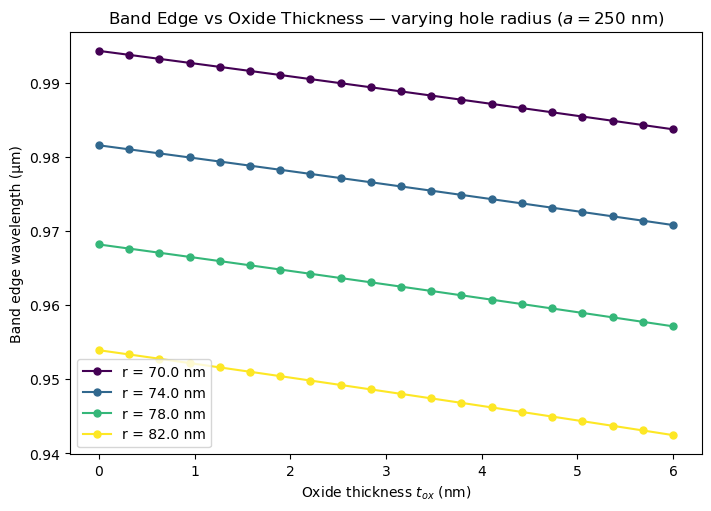

In [39]:
# ---- Band edge vs oxide thickness for different hole radii (fixed a) ----
a_fixed = 250                                 # fixed lattice constant (nm)
r_sweep = np.linspace(70, 82, 4)             # hole radii to compare (nm)
t_ox_sweep_fine = np.linspace(0, 6, 20)      # oxide thickness sweep (nm)

sweep_r_results = {}
n_total = len(r_sweep) * len(t_ox_sweep_fine)
count = 0

for r_val in r_sweep:
    lam_arr = []
    for t_ox_nm in t_ox_sweep_fine:
        count += 1
        t_ox_norm = t_ox_nm / a_fixed
        lam = compute_band_edge(a_fixed, r_val, t_ox=t_ox_norm)
        lam_arr.append(lam)
        print(f"[{count}/{n_total}] r={r_val:.1f}nm, t_ox={t_ox_nm:.1f}nm → λ_edge={lam:.4f} µm")
    sweep_r_results[r_val] = np.array(lam_arr)

print("\nSweep complete.")

# ---- Plot ----
fig, ax = plt.subplots(constrained_layout=True, figsize=(7, 5))
cmap = plt.cm.viridis
colors = [cmap(i / max(len(r_sweep) - 1, 1)) for i in range(len(r_sweep))]

for r_val, c in zip(r_sweep, colors):
    ax.plot(t_ox_sweep_fine, sweep_r_results[r_val], 'o-', color=c,
            markersize=5, linewidth=1.5, label=f'r = {r_val:.1f} nm')

ax.set_xlabel(r'Oxide thickness $t_{ox}$ (nm)')
ax.set_ylabel(r'Band edge wavelength (µm)')
ax.set_title(f'Band Edge vs Oxide Thickness — varying hole radius ($a = {a_fixed}$ nm)')
ax.legend()
plt.show()

[1/80] a=246nm, t_ox=0.0nm → λ_edge=0.9617 µm
[2/80] a=246nm, t_ox=0.3nm → λ_edge=0.9611 µm
[3/80] a=246nm, t_ox=0.6nm → λ_edge=0.9606 µm
[4/80] a=246nm, t_ox=0.9nm → λ_edge=0.9600 µm
[5/80] a=246nm, t_ox=1.3nm → λ_edge=0.9595 µm
[6/80] a=246nm, t_ox=1.6nm → λ_edge=0.9589 µm
[7/80] a=246nm, t_ox=1.9nm → λ_edge=0.9583 µm
[8/80] a=246nm, t_ox=2.2nm → λ_edge=0.9578 µm
[9/80] a=246nm, t_ox=2.5nm → λ_edge=0.9572 µm
[10/80] a=246nm, t_ox=2.8nm → λ_edge=0.9566 µm
[11/80] a=246nm, t_ox=3.2nm → λ_edge=0.9561 µm
[12/80] a=246nm, t_ox=3.5nm → λ_edge=0.9555 µm
[13/80] a=246nm, t_ox=3.8nm → λ_edge=0.9549 µm
[14/80] a=246nm, t_ox=4.1nm → λ_edge=0.9543 µm
[15/80] a=246nm, t_ox=4.4nm → λ_edge=0.9538 µm
[16/80] a=246nm, t_ox=4.7nm → λ_edge=0.9532 µm
[17/80] a=246nm, t_ox=5.1nm → λ_edge=0.9526 µm
[18/80] a=246nm, t_ox=5.4nm → λ_edge=0.9520 µm
[19/80] a=246nm, t_ox=5.7nm → λ_edge=0.9514 µm
[20/80] a=246nm, t_ox=6.0nm → λ_edge=0.9508 µm
[21/80] a=248nm, t_ox=0.0nm → λ_edge=0.9700 µm
[22/80] a=248nm, t_ox=

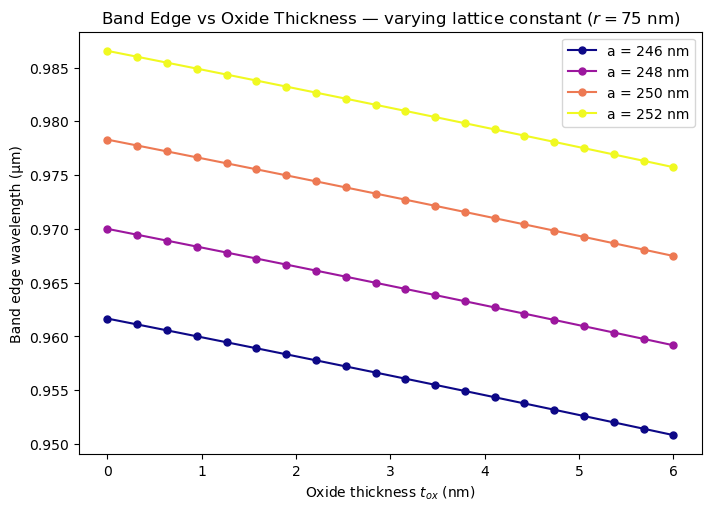

In [40]:
# ---- Band edge vs oxide thickness for different lattice constants (fixed r) ----
r_fixed = 75                                  # fixed hole radius (nm)
a_sweep = np.linspace(246, 252, 4)           # lattice constants to compare (nm)

sweep_a_results = {}
n_total = len(a_sweep) * len(t_ox_sweep_fine)
count = 0

for a_val in a_sweep:
    lam_arr = []
    for t_ox_nm in t_ox_sweep_fine:
        count += 1
        t_ox_norm = t_ox_nm / a_val
        lam = compute_band_edge(a_val, r_fixed, t_ox=t_ox_norm)
        lam_arr.append(lam)
        print(f"[{count}/{n_total}] a={a_val:.0f}nm, t_ox={t_ox_nm:.1f}nm → λ_edge={lam:.4f} µm")
    sweep_a_results[a_val] = np.array(lam_arr)

print("\nSweep complete.")

# ---- Plot ----
fig, ax = plt.subplots(constrained_layout=True, figsize=(7, 5))
cmap = plt.cm.plasma
colors = [cmap(i / max(len(a_sweep) - 1, 1)) for i in range(len(a_sweep))]

for a_val, c in zip(a_sweep, colors):
    ax.plot(t_ox_sweep_fine, sweep_a_results[a_val], 'o-', color=c,
            markersize=5, linewidth=1.5, label=f'a = {a_val:.0f} nm')

ax.set_xlabel(r'Oxide thickness $t_{ox}$ (nm)')
ax.set_ylabel(r'Band edge wavelength (µm)')
ax.set_title(f'Band Edge vs Oxide Thickness — varying lattice constant ($r = {r_fixed}$ nm)')
ax.legend()
plt.show()

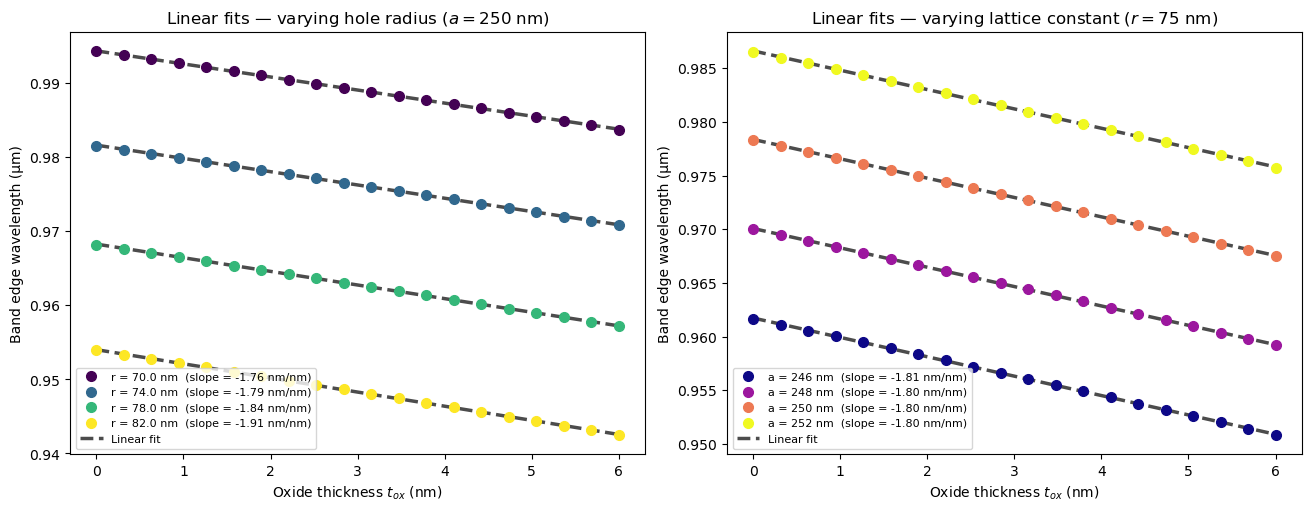

LINEAR FIT SLOPES:  dλ_edge / dt_ox

Varying hole radius (a = 250 nm):
      r (nm)   slope (nm/nm)
  ----------  --------------
        70.0          -1.764
        74.0          -1.793
        78.0          -1.841
        82.0          -1.910

Varying lattice constant (r = 75 nm):
      a (nm)   slope (nm/nm)
  ----------  --------------
         246          -1.806
         248          -1.804
         250          -1.803
         252          -1.802

Mean slope:  -1.815 nm/nm
Std dev:     0.041 nm/nm


In [ ]:
# ---- Linear fits: extract dλ/dt_ox slope ----
t_fit = np.linspace(t_ox_sweep_fine[0], t_ox_sweep_fine[-1], 100)

# Fit each curve
fits_r = {}  # {r_val: (slope, intercept)}
for r_val in r_sweep:
    slope, intercept = np.polyfit(t_ox_sweep_fine, sweep_r_results[r_val], 1)
    fits_r[r_val] = (slope, intercept)

fits_a = {}  # {a_val: (slope, intercept)}
for a_val in a_sweep:
    slope, intercept = np.polyfit(t_ox_sweep_fine, sweep_a_results[a_val], 1)
    fits_a[a_val] = (slope, intercept)

# ---- Plot: data + fit lines ----
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(13, 5))

# Left: varying r
cmap1 = plt.cm.viridis
colors1 = [cmap1(i / max(len(r_sweep) - 1, 1)) for i in range(len(r_sweep))]
for r_val, c in zip(r_sweep, colors1):
    slope, intercept = fits_r[r_val]
    ax1.plot(t_ox_sweep_fine, sweep_r_results[r_val], 'o', color=c,
             markersize=7, zorder=3)
    ax1.plot(t_fit, slope * t_fit + intercept, '--', color='k',
             linewidth=2.5, alpha=0.7, zorder=2)
    # invisible line just for the legend entry combining color + slope
    ax1.plot([], [], 'o', color=c, markersize=7,
             label=f'r = {r_val:.1f} nm  (slope = {slope*1e3:.2f} nm/nm)')
ax1.plot([], [], '--', color='k', linewidth=2.5, alpha=0.7, label='Linear fit')
ax1.set_xlabel(r'Oxide thickness $t_{ox}$ (nm)')
ax1.set_ylabel(r'Band edge wavelength (µm)')
ax1.set_title(f'Linear fits — varying hole radius ($a = {a_fixed}$ nm)')
ax1.legend(fontsize=8)

# Right: varying a
cmap2 = plt.cm.plasma
colors2 = [cmap2(i / max(len(a_sweep) - 1, 1)) for i in range(len(a_sweep))]
for a_val, c in zip(a_sweep, colors2):
    slope, intercept = fits_a[a_val]
    ax2.plot(t_ox_sweep_fine, sweep_a_results[a_val], 'o', color=c,
             markersize=7, zorder=3)
    ax2.plot(t_fit, slope * t_fit + intercept, '--', color='k',
             linewidth=2.5, alpha=0.7, zorder=2)
    ax2.plot([], [], 'o', color=c, markersize=7,
             label=f'a = {a_val:.0f} nm  (slope = {slope*1e3:.2f} nm/nm)')
ax2.plot([], [], '--', color='k', linewidth=2.5, alpha=0.7, label='Linear fit')
ax2.set_xlabel(r'Oxide thickness $t_{ox}$ (nm)')
ax2.set_ylabel(r'Band edge wavelength (µm)')
ax2.set_title(f'Linear fits — varying lattice constant ($r = {r_fixed}$ nm)')
ax2.legend(fontsize=8)

plt.show()

# ---- Summary table ----
print("=" * 60)
print("LINEAR FIT SLOPES:  dλ_edge / dt_ox")
print("=" * 60)
print(f"\nVarying hole radius (a = {a_fixed} nm):")
print(f"  {'r (nm)':>10}  {'slope (nm/nm)':>14}")
print(f"  {'-'*10}  {'-'*14}")
for r_val in r_sweep:
    s = fits_r[r_val][0] * 1e3  # µm/nm → nm/nm
    print(f"  {r_val:>10.1f}  {s:>14.3f}")

print(f"\nVarying lattice constant (r = {r_fixed} nm):")
print(f"  {'a (nm)':>10}  {'slope (nm/nm)':>14}")
print(f"  {'-'*10}  {'-'*14}")
for a_val in a_sweep:
    s = fits_a[a_val][0] * 1e3  # µm/nm → nm/nm
    print(f"  {a_val:>10.0f}  {s:>14.3f}")
# Overall average
all_slopes = [fits_r[r][0]*1e3 for r in r_sweep] + [fits_a[a][0]*1e3 for a in a_sweep]
print(f"\nMean slope:  {np.mean(all_slopes):.3f} nm/nm")
print(f"Std dev:     {np.std(all_slopes):.3f} nm/nm")
print("=" * 60)

In [13]:
import os
from datetime import datetime

SAVE_DATA = True

def save_sweep(name, arrays_dict, **extra_params):
    """Save sweep results to a timestamped folder in data/."""
    if not SAVE_DATA:
        return
    timestamp = datetime.now().strftime('%Y-%m-%d_%H%M%S')
    folder = os.path.join('data', f'{timestamp}_{name}')
    os.makedirs(folder, exist_ok=True)

    for label, arr in arrays_dict.items():
        np.save(os.path.join(folder, f'{label}.npy'), np.asarray(arr))

    with open(os.path.join(folder, 'info.txt'), 'w') as f:
        f.write(f'Sweep: {name}\n')
        f.write(f'Date: {timestamp}\n\n')
        f.write('--- Physical parameters ---\n')
        f.write(f'a_nm = {a_nm}\n')
        f.write(f'ra = {ra:.4f} ({ra * a_nm:.1f} nm)\n')
        f.write(f'D = {D:.4f} ({D * a_nm:.1f} nm)\n')
        f.write(f'n_slab = {n_slab}\n')
        f.write(f'n_oxide = {n_oxide}\n')
        f.write(f'eps_oxide = {eps_oxide:.4f}\n\n')
        f.write('--- Supercell ---\n')
        f.write(f'Nx = {Nx}, Ny = {Ny}\n')
        f.write(f'Nholes = {Nholes}\n\n')
        f.write('--- GME settings ---\n')
        f.write(f'gmax = {gmax}\n')
        f.write(f'truncate_g = {truncate_g}\n')
        f.write(f'numeig = {numeig}\n')
        f.write(f'gmode_inds = {gmode_inds}\n')
        f.write(f'kz_symmetry = {kz_symmetry}\n')
        f.write(f'b_target = {b_target}\n\n')
        f.write('--- Sweep-specific parameters ---\n')
        for k, v in extra_params.items():
            f.write(f'{k} = {v}\n')
        f.write(f'\n--- Saved arrays ---\n')
        for label in arrays_dict:
            f.write(f'{label}.npy\n')

    print(f'Results saved to {folder}/')

## Band Edge vs Oxide Thickness: Consume Ratio Sweep
Sweep oxide thickness for different `consume_ratio` values (0.4–1.0),
using standard parameters (a = 250 nm, r = 75 nm).

[1/120] cr=0.00, t_ox=0.0nm → λ_edge=0.9783 µm
[2/120] cr=0.00, t_ox=0.3nm → λ_edge=0.9786 µm
[3/120] cr=0.00, t_ox=0.6nm → λ_edge=0.9790 µm
[4/120] cr=0.00, t_ox=0.9nm → λ_edge=0.9793 µm
[5/120] cr=0.00, t_ox=1.3nm → λ_edge=0.9796 µm
[6/120] cr=0.00, t_ox=1.6nm → λ_edge=0.9799 µm
[7/120] cr=0.00, t_ox=1.9nm → λ_edge=0.9802 µm
[8/120] cr=0.00, t_ox=2.2nm → λ_edge=0.9806 µm
[9/120] cr=0.00, t_ox=2.5nm → λ_edge=0.9809 µm
[10/120] cr=0.00, t_ox=2.8nm → λ_edge=0.9812 µm
[11/120] cr=0.00, t_ox=3.2nm → λ_edge=0.9815 µm
[12/120] cr=0.00, t_ox=3.5nm → λ_edge=0.9818 µm
[13/120] cr=0.00, t_ox=3.8nm → λ_edge=0.9821 µm
[14/120] cr=0.00, t_ox=4.1nm → λ_edge=0.9824 µm
[15/120] cr=0.00, t_ox=4.4nm → λ_edge=0.9827 µm
[16/120] cr=0.00, t_ox=4.7nm → λ_edge=0.9830 µm
[17/120] cr=0.00, t_ox=5.1nm → λ_edge=0.9833 µm
[18/120] cr=0.00, t_ox=5.4nm → λ_edge=0.9836 µm
[19/120] cr=0.00, t_ox=5.7nm → λ_edge=0.9839 µm
[20/120] cr=0.00, t_ox=6.0nm → λ_edge=0.9842 µm
[21/120] cr=0.20, t_ox=0.0nm → λ_edge=0.9783 µm
[

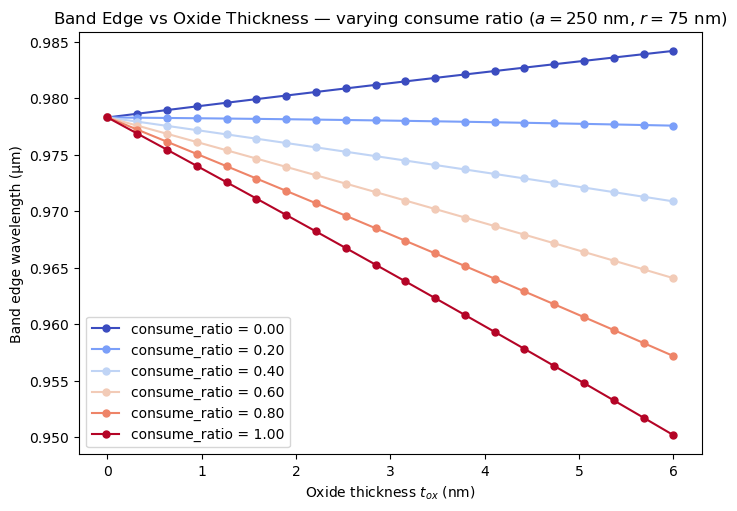

Results saved to data/2026-03-17_141415_wg_consume_ratio_oxide/


In [16]:
cr_list = np.linspace(0, 1.0, 6)
t_ox_cr = np.linspace(0, 6, 20)

sweep_cr_results = {}
n_total = len(cr_list) * len(t_ox_cr)
count = 0

for cr in cr_list:
    lam_arr = []
    for t_ox_nm in t_ox_cr:
        count += 1
        t_ox_norm = t_ox_nm / a_nm
        lam = compute_band_edge(a_nm, 75, t_ox=t_ox_norm, consume_ratio=cr)
        lam_arr.append(lam)
        print(f"[{count}/{n_total}] cr={cr:.2f}, t_ox={t_ox_nm:.1f}nm → λ_edge={lam:.4f} µm")
    sweep_cr_results[cr] = np.array(lam_arr)

print("\nSweep complete.")

# Plot
fig, ax = plt.subplots(constrained_layout=True, figsize=(7, 5))
cmap = plt.cm.coolwarm
colors = [cmap(i / max(len(cr_list) - 1, 1)) for i in range(len(cr_list))]

for cr, c in zip(cr_list, colors):
    ax.plot(t_ox_cr, sweep_cr_results[cr], 'o-', color=c,
            markersize=5, linewidth=1.5, label=f'consume_ratio = {cr:.2f}')

ax.set_xlabel(r'Oxide thickness $t_{ox}$ (nm)')
ax.set_ylabel(r'Band edge wavelength (µm)')
ax.set_title(f'Band Edge vs Oxide Thickness — varying consume ratio ($a = {a_nm}$ nm, $r = 75$ nm)')
ax.legend()
plt.show()

# Save
if SAVE_DATA:
    arrays = {'t_ox_nm': t_ox_cr, 'cr_list': np.array(cr_list)}
    for cr in cr_list:
        arrays[f'lam_cr{cr:.2f}'] = sweep_cr_results[cr]
    save_sweep('wg_consume_ratio_oxide', arrays, a_nm=a_nm, r_nm=75,
               cr_list=cr_list.tolist())

## Consume Ratio Sweep: Hole-Only Oxidation
Same sweep as above but oxide grows only on hole sidewalls —
no top/bottom oxide cladding layers and no slab thinning.

[1/120] cr=0.00, t_ox=0.0nm → λ_edge=0.9783 µm
[2/120] cr=0.00, t_ox=0.3nm → λ_edge=0.9785 µm
[3/120] cr=0.00, t_ox=0.6nm → λ_edge=0.9787 µm
[4/120] cr=0.00, t_ox=0.9nm → λ_edge=0.9789 µm
[5/120] cr=0.00, t_ox=1.3nm → λ_edge=0.9790 µm
[6/120] cr=0.00, t_ox=1.6nm → λ_edge=0.9792 µm
[7/120] cr=0.00, t_ox=1.9nm → λ_edge=0.9794 µm
[8/120] cr=0.00, t_ox=2.2nm → λ_edge=0.9796 µm
[9/120] cr=0.00, t_ox=2.5nm → λ_edge=0.9798 µm
[10/120] cr=0.00, t_ox=2.8nm → λ_edge=0.9799 µm
[11/120] cr=0.00, t_ox=3.2nm → λ_edge=0.9801 µm
[12/120] cr=0.00, t_ox=3.5nm → λ_edge=0.9803 µm
[13/120] cr=0.00, t_ox=3.8nm → λ_edge=0.9805 µm
[14/120] cr=0.00, t_ox=4.1nm → λ_edge=0.9807 µm
[15/120] cr=0.00, t_ox=4.4nm → λ_edge=0.9808 µm
[16/120] cr=0.00, t_ox=4.7nm → λ_edge=0.9810 µm
[17/120] cr=0.00, t_ox=5.1nm → λ_edge=0.9812 µm
[18/120] cr=0.00, t_ox=5.4nm → λ_edge=0.9814 µm
[19/120] cr=0.00, t_ox=5.7nm → λ_edge=0.9815 µm
[20/120] cr=0.00, t_ox=6.0nm → λ_edge=0.9817 µm
[21/120] cr=0.20, t_ox=0.0nm → λ_edge=0.9783 µm
[

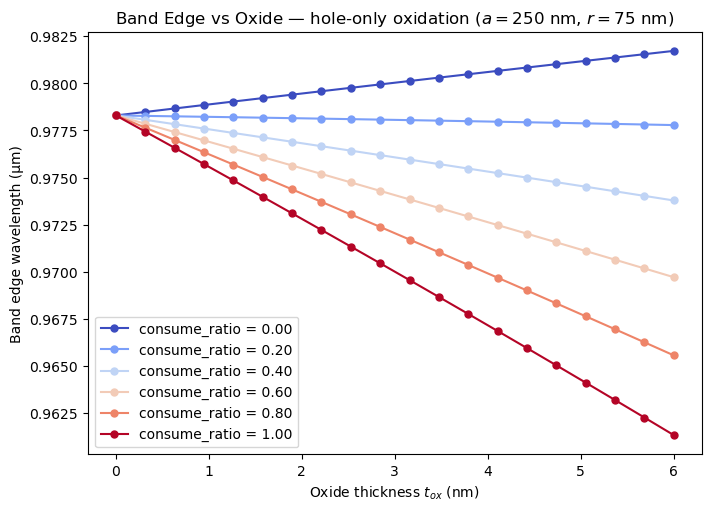

Results saved to data/2026-03-17_142941_wg_consume_ratio_hole_only/


In [18]:
cr_list_ho = np.linspace(0, 1.0, 6)
t_ox_cr_ho = np.linspace(0, 6, 20)

sweep_cr_hole_only = {}
n_total = len(cr_list_ho) * len(t_ox_cr_ho)
count = 0

for cr in cr_list_ho:
    lam_arr = []
    for t_ox_nm in t_ox_cr_ho:
        count += 1
        t_ox_norm = t_ox_nm / a_nm
        lam = compute_band_edge(a_nm, 75, t_ox=t_ox_norm, consume_ratio=cr, hole_only=True)
        lam_arr.append(lam)
        print(f"[{count}/{n_total}] cr={cr:.2f}, t_ox={t_ox_nm:.1f}nm → λ_edge={lam:.4f} µm")
    sweep_cr_hole_only[cr] = np.array(lam_arr)

print("\nSweep complete.")

# Plot
fig, ax = plt.subplots(constrained_layout=True, figsize=(7, 5))
cmap = plt.cm.coolwarm
colors = [cmap(i / max(len(cr_list_ho) - 1, 1)) for i in range(len(cr_list_ho))]

for cr, c in zip(cr_list_ho, colors):
    ax.plot(t_ox_cr_ho, sweep_cr_hole_only[cr], 'o-', color=c,
            markersize=5, linewidth=1.5, label=f'consume_ratio = {cr:.2f}')

ax.set_xlabel(r'Oxide thickness $t_{ox}$ (nm)')
ax.set_ylabel(r'Band edge wavelength (µm)')
ax.set_title(f'Band Edge vs Oxide — hole-only oxidation ($a = {a_nm}$ nm, $r = 75$ nm)')
ax.legend()
plt.show()

# Save
if SAVE_DATA:
    arrays = {'t_ox_nm': t_ox_cr_ho, 'cr_list': np.array(cr_list_ho)}
    for cr in cr_list_ho:
        arrays[f'lam_cr{cr:.2f}'] = sweep_cr_hole_only[cr]
    save_sweep('wg_consume_ratio_hole_only', arrays, a_nm=a_nm, r_nm=75,
               cr_list=cr_list_ho.tolist(), hole_only=True)

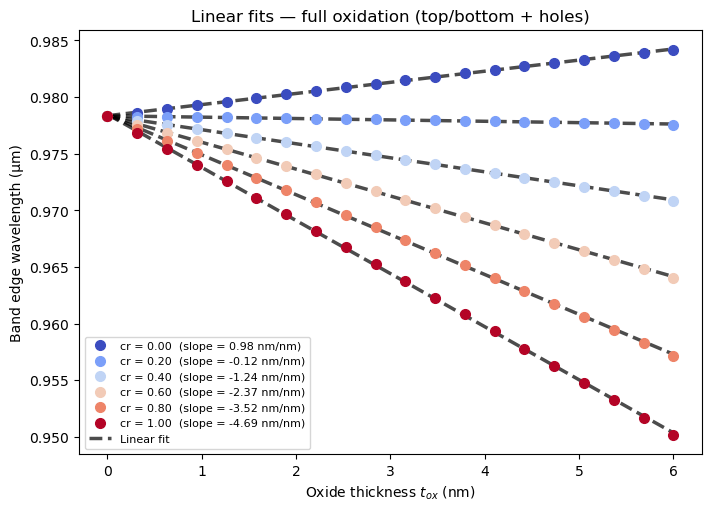

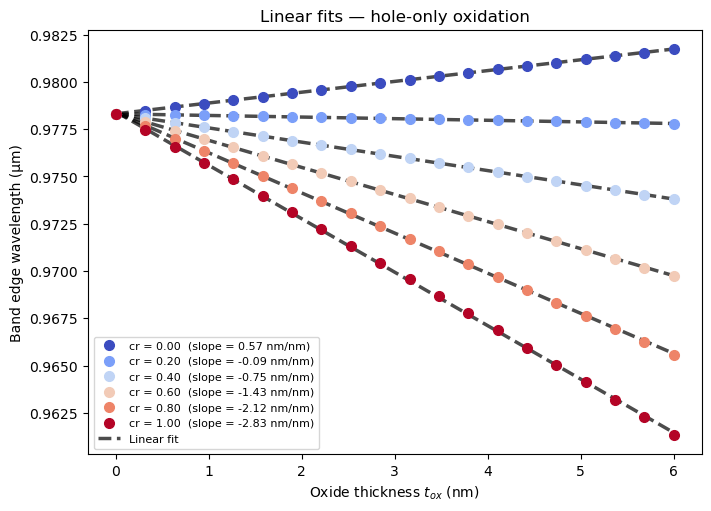

LINEAR FIT SLOPES:  dλ_edge / dt_ox  (consume ratio sweeps)

    cr    Full (nm/nm)   Hole-only (nm/nm)
------  --------------  ------------------
  0.00           0.982               0.571
  0.20          -0.121              -0.085
  0.40          -1.239              -0.752
  0.60          -2.371              -1.431
  0.80          -3.520              -2.122
  1.00          -4.686              -2.827

Full oxidation — mean: -1.826, std: 1.936 nm/nm
Hole-only      — mean: -1.107, std: 1.160 nm/nm


In [20]:
# ---- Linear fits: consume ratio sweeps (loaded from saved data) ----
data_full = 'data/2026-03-17_141415_wg_consume_ratio_oxide'
data_ho   = 'data/2026-03-17_142941_wg_consume_ratio_hole_only'

# Load data
t_ox_full = np.load(os.path.join(data_full, 't_ox_nm.npy'))
cr_full   = np.load(os.path.join(data_full, 'cr_list.npy'))
lam_full  = {cr: np.load(os.path.join(data_full, f'lam_cr{cr:.2f}.npy')) for cr in cr_full}

t_ox_ho = np.load(os.path.join(data_ho, 't_ox_nm.npy'))
cr_ho   = np.load(os.path.join(data_ho, 'cr_list.npy'))
lam_ho  = {cr: np.load(os.path.join(data_ho, f'lam_cr{cr:.2f}.npy')) for cr in cr_ho}

# Fit each curve
fits_full = {}
for cr in cr_full:
    slope, intercept = np.polyfit(t_ox_full, lam_full[cr], 1)
    fits_full[cr] = (slope, intercept)

fits_ho = {}
for cr in cr_ho:
    slope, intercept = np.polyfit(t_ox_ho, lam_ho[cr], 1)
    fits_ho[cr] = (slope, intercept)

t_fit_full = np.linspace(t_ox_full[0], t_ox_full[-1], 100)
t_fit_ho   = np.linspace(t_ox_ho[0], t_ox_ho[-1], 100)
cmap = plt.cm.coolwarm

# ---- Plot 1: Full oxidation ----
fig1, ax1 = plt.subplots(constrained_layout=True, figsize=(7, 5))
colors_full = [cmap(i / max(len(cr_full) - 1, 1)) for i in range(len(cr_full))]
for cr, c in zip(cr_full, colors_full):
    slope, intercept = fits_full[cr]
    ax1.plot(t_ox_full, lam_full[cr], 'o', color=c, markersize=7, zorder=3)
    ax1.plot(t_fit_full, slope * t_fit_full + intercept, '--', color='k',
             linewidth=2.5, alpha=0.7, zorder=2)
    ax1.plot([], [], 'o', color=c, markersize=7,
             label=f'cr = {cr:.2f}  (slope = {slope*1e3:.2f} nm/nm)')
ax1.plot([], [], '--', color='k', linewidth=2.5, alpha=0.7, label='Linear fit')
ax1.set_xlabel(r'Oxide thickness $t_{ox}$ (nm)')
ax1.set_ylabel(r'Band edge wavelength (µm)')
ax1.set_title('Linear fits — full oxidation (top/bottom + holes)')
ax1.legend(fontsize=8)
plt.show()

# ---- Plot 2: Hole-only oxidation ----
fig2, ax2 = plt.subplots(constrained_layout=True, figsize=(7, 5))
colors_ho = [cmap(i / max(len(cr_ho) - 1, 1)) for i in range(len(cr_ho))]
for cr, c in zip(cr_ho, colors_ho):
    slope, intercept = fits_ho[cr]
    ax2.plot(t_ox_ho, lam_ho[cr], 'o', color=c, markersize=7, zorder=3)
    ax2.plot(t_fit_ho, slope * t_fit_ho + intercept, '--', color='k',
             linewidth=2.5, alpha=0.7, zorder=2)
    ax2.plot([], [], 'o', color=c, markersize=7,
             label=f'cr = {cr:.2f}  (slope = {slope*1e3:.2f} nm/nm)')
ax2.plot([], [], '--', color='k', linewidth=2.5, alpha=0.7, label='Linear fit')
ax2.set_xlabel(r'Oxide thickness $t_{ox}$ (nm)')
ax2.set_ylabel(r'Band edge wavelength (µm)')
ax2.set_title('Linear fits — hole-only oxidation')
ax2.legend(fontsize=8)
plt.show()

# ---- Summary table ----
print("=" * 70)
print("LINEAR FIT SLOPES:  dλ_edge / dt_ox  (consume ratio sweeps)")
print("=" * 70)
print(f"\n{'cr':>6}  {'Full (nm/nm)':>14}  {'Hole-only (nm/nm)':>18}")
print(f"{'-'*6}  {'-'*14}  {'-'*18}")
for cr in cr_full:
    s_f = fits_full[cr][0] * 1e3
    s_h = fits_ho[cr][0] * 1e3
    print(f"{cr:>6.2f}  {s_f:>14.3f}  {s_h:>18.3f}")

all_full = [fits_full[cr][0]*1e3 for cr in cr_full]
all_ho   = [fits_ho[cr][0]*1e3 for cr in cr_ho]
print(f"\nFull oxidation — mean: {np.mean(all_full):.3f}, std: {np.std(all_full):.3f} nm/nm")
print(f"Hole-only      — mean: {np.mean(all_ho):.3f}, std: {np.std(all_ho):.3f} nm/nm")
print("=" * 70)